# Diffusion SBI Smoke Test: Analytic Gaussian Conditionals

This notebook is the first validation rung for the experimental conditional diffusion SBI model.

The data are deliberately simple: a known five-dimensional joint Gaussian, arranged as

```text
[phot_1, phot_2, phot_3, theta_1, theta_2]
```

Because the joint distribution is known analytically, every conditional posterior can be computed exactly. The diffusion model is trained on joint samples and then asked to sample unknown coordinates while clamping known coordinates.

This is not a physical SED validation. It checks the diffusion machinery: feature order, masks, standardization, device/dtype handling, reverse sampler, and conditional inpainting.

## Scientific Data Flow

1. Draw training and held-out rows from a fixed positive-definite Gaussian.
2. Train `ConditionalDiffusionEstimator` on the full joint feature vector.
3. Use a mask convention where `True = known/clamped` and `False = unknown/sampled`.
4. Evaluate three conditionals: inverse `theta | photometry`, forward `photometry | theta`, and mixed inpainting.
5. Compare diffusion samples to the exact Gaussian conditional means/covariances.
6. Save and display training loss, rank/coverage summaries, and one analytic conditional ellipse plot.

Important audit points live in `examples/experimental_diffusion_gaussian_conditionals.py`: `make_joint_gaussian`, `gaussian_conditional`, `evaluate_case`, and `run_validation`.

In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
for root in candidate_roots:
    if (root / "examples" / "experimental_diffusion_gaussian_conditionals.py").exists():
        PROJECT_ROOT = root
        break
else:
    raise RuntimeError("Could not find the CompoSED repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from examples.experimental_diffusion_gaussian_conditionals import run_validation
print("Project root:", PROJECT_ROOT)

Project root: /Users/gregoire/Documents/Sedfitting/CompoSED


In [2]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "diffusion_gaussian_conditionals_notebook"

metrics = run_validation(
    n_train=4096,
    n_test=48,
    epochs=80,
    num_samples=512,
    steps=40,
    seed=20260706,
    output_dir=OUTPUT_DIR,
)
metrics

epoch 1/80: train_loss=0.941007


epoch 2/80: train_loss=0.792754


epoch 3/80: train_loss=0.772448
epoch 4/80: train_loss=0.75804


epoch 5/80: train_loss=0.769471
epoch 6/80: train_loss=0.765427


epoch 7/80: train_loss=0.759791
epoch 8/80: train_loss=0.763365


...

epoch 68/80: train_loss=0.71898
epoch 69/80: train_loss=0.731177
epoch 70/80: train_loss=0.730088


epoch 71/80: train_loss=0.729122
epoch 72/80: train_loss=0.731689
epoch 73/80: train_loss=0.745013
epoch 74/80: train_loss=0.718389


epoch 75/80: train_loss=0.72807
epoch 76/80: train_loss=0.734699
epoch 77/80: train_loss=0.747646
epoch 78/80: train_loss=0.731473


epoch 79/80: train_loss=0.710584
epoch 80/80: train_loss=0.719619


{'device': 'mps',
 'final_train_loss': 0.7196191027760506,
 'n_epochs': 80,
 'cases': {'inverse_theta_given_photometry': {'known_features': ['phot_1',
    'phot_2',
    'phot_3'],
   'unknown_features': ['theta_1', 'theta_2'],
   'seconds': 0.17867487500188872,
   'mean_rmse': 0.24899792085516836,
   'std_relative_error': 0.053787054345456504,
   'known_max_abs_error': 0.0,
   'coverage_68': {'theta_1': 0.6458333333333334, 'theta_2': 0.625}},
  'forward_photometry_given_theta': {'known_features': ['theta_1', 'theta_2'],
   'unknown_features': ['phot_1', 'phot_2', 'phot_3'],
   'seconds': 0.15738699998473749,
   'mean_rmse': 0.2846498463922778,
   'std_relative_error': 0.04939138116946501,
   'known_max_abs_error': 0.0,
   'coverage_68': {'phot_1': 0.6875,
    'phot_2': 0.5833333333333334,
    'phot_3': 0.6875}},
  'mixed_inpainting': {'known_features': ['phot_1', 'theta_1'],
   'unknown_features': ['phot_2', 'phot_3', 'theta_2'],
   'seconds': 0.15429137498722412,
   'mean_rmse': 0.367

## Key Checks

The first hard check is exact clamping. If any known coordinate moves during sampling, this notebook should fail.

The remaining metrics are smoke-level numerical checks: we expect approximate agreement with the analytic conditional, not publication-level calibration from this short run.

In [3]:
for case_name, case in metrics["cases"].items():
    print(case_name)
    print("  known features:", case["known_features"])
    print("  unknown features:", case["unknown_features"])
    print("  known max abs error:", case["known_max_abs_error"])
    print("  conditional mean RMSE:", case["mean_rmse"])
    print("  std relative error:", case["std_relative_error"])
    print("  68% coverage:", case["coverage_68"])
    print()

inverse_theta_given_photometry
  known features: ['phot_1', 'phot_2', 'phot_3']
  unknown features: ['theta_1', 'theta_2']
  known max abs error: 0.0
  conditional mean RMSE: 0.24899792085516836
  std relative error: 0.053787054345456504
  68% coverage: {'theta_1': 0.6458333333333334, 'theta_2': 0.625}

forward_photometry_given_theta
  known features: ['theta_1', 'theta_2']
  unknown features: ['phot_1', 'phot_2', 'phot_3']
  known max abs error: 0.0
  conditional mean RMSE: 0.2846498463922778
  std relative error: 0.04939138116946501
  68% coverage: {'phot_1': 0.6875, 'phot_2': 0.5833333333333334, 'phot_3': 0.6875}

mixed_inpainting
  known features: ['phot_1', 'theta_1']
  unknown features: ['phot_2', 'phot_3', 'theta_2']
  known max abs error: 0.0
  conditional mean RMSE: 0.36744223553381855
  std relative error: 0.05441500526361468
  68% coverage: {'phot_2': 0.6666666666666666, 'phot_3': 0.5625, 'theta_2': 0.5833333333333334}



training_loss.png


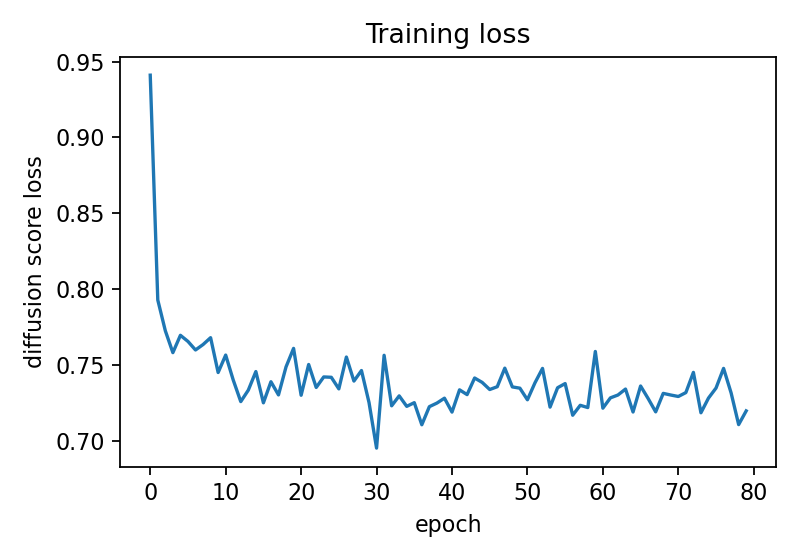

inverse_theta_given_photometry_summary.png


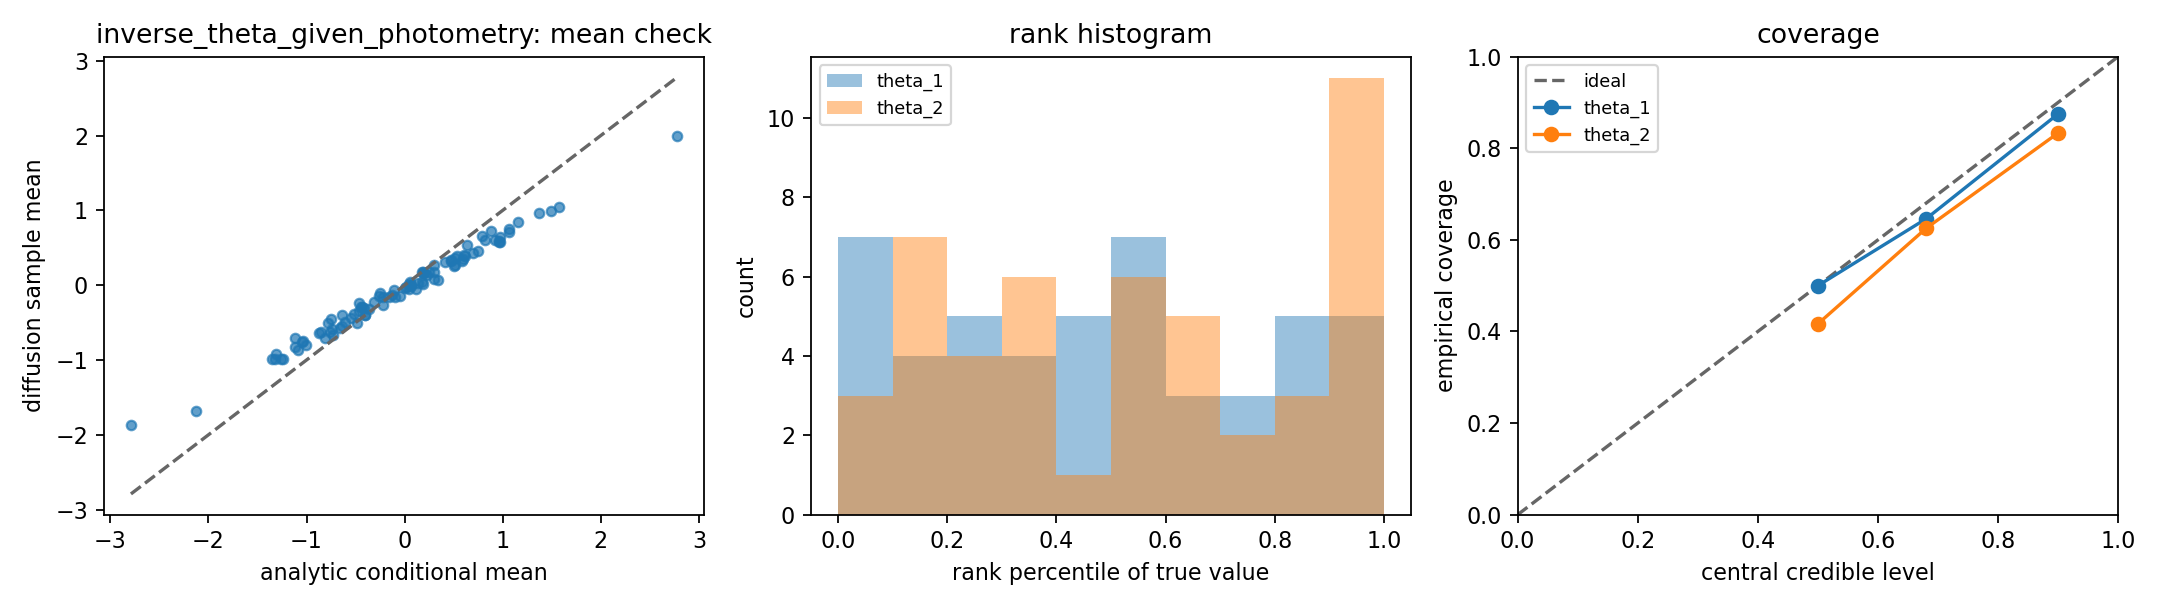

forward_photometry_given_theta_summary.png


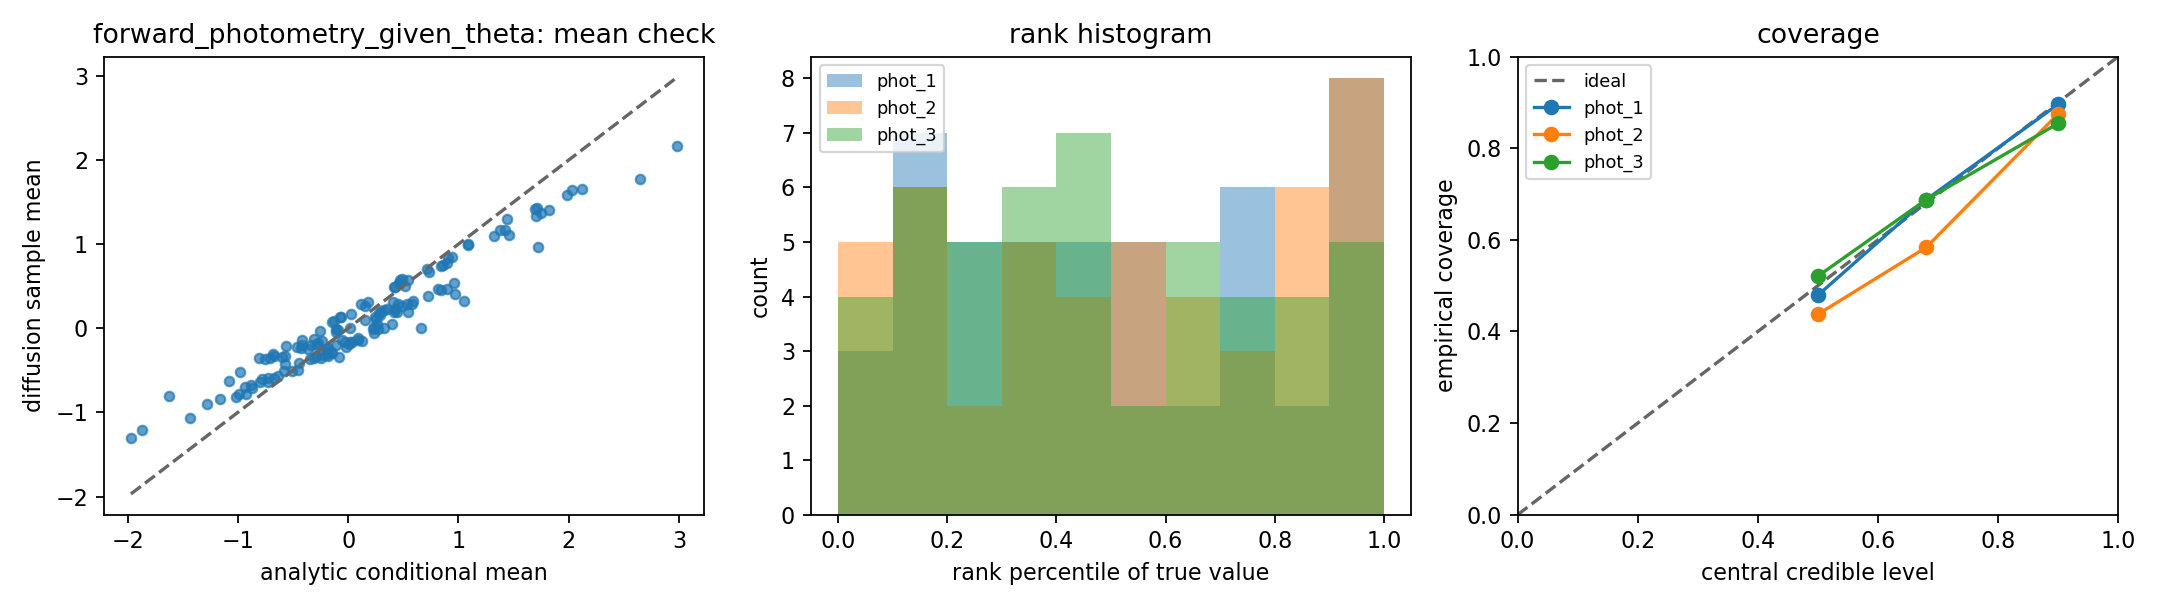

mixed_inpainting_summary.png


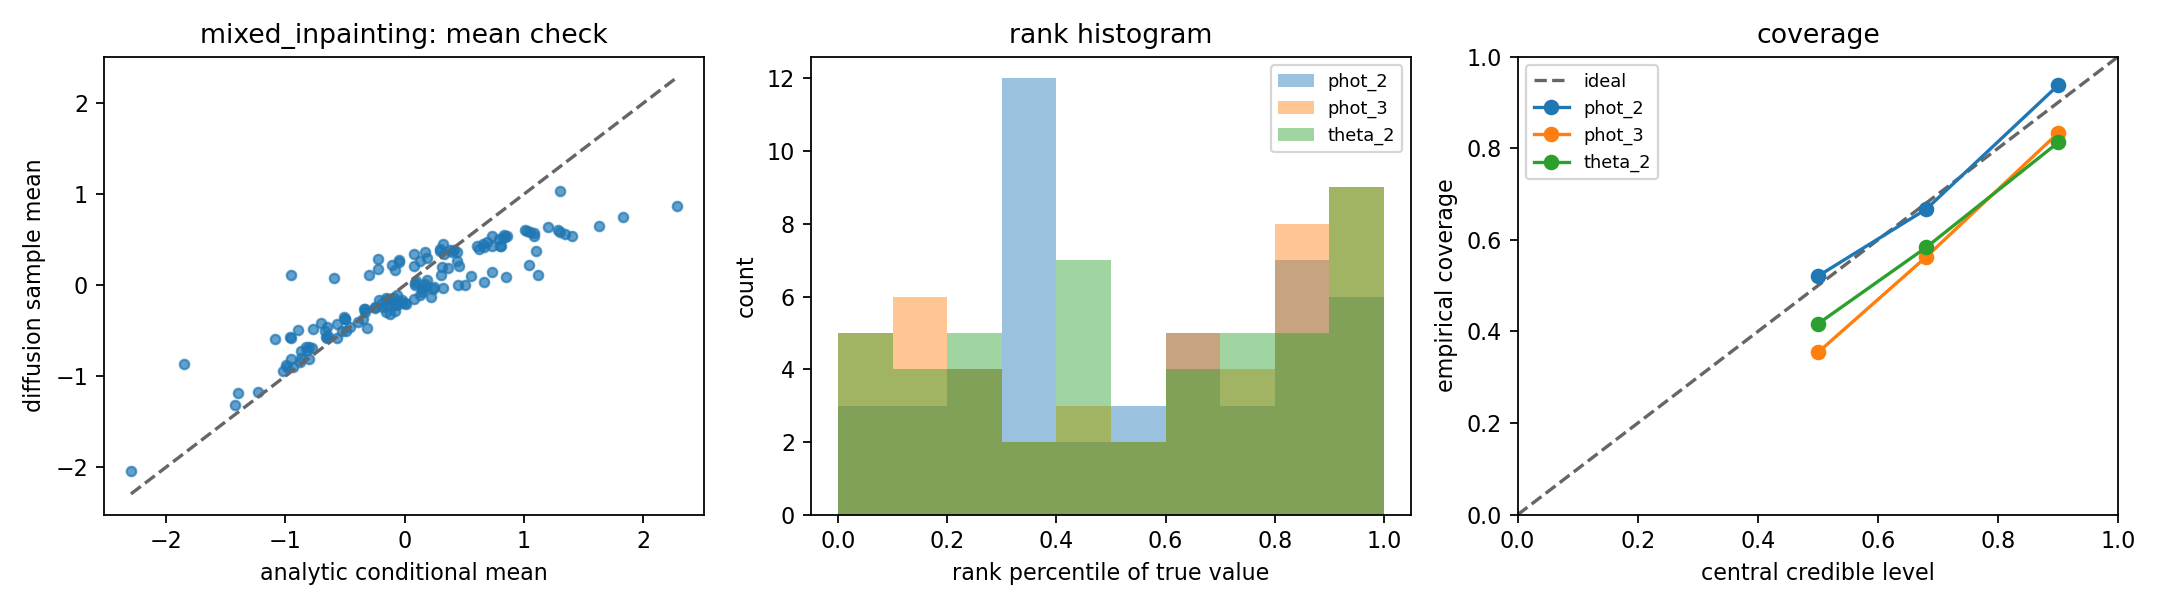

inverse_posterior_ellipse.png


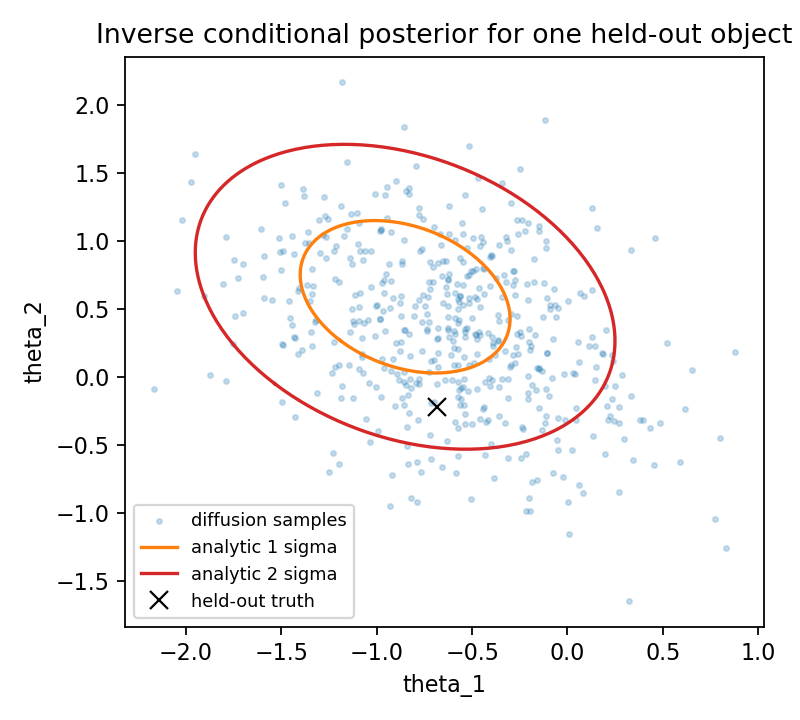

In [4]:
from IPython.display import Image, display

for filename in [
    "training_loss.png",
    "inverse_theta_given_photometry_summary.png",
    "forward_photometry_given_theta_summary.png",
    "mixed_inpainting_summary.png",
    "inverse_posterior_ellipse.png",
]:
    print(filename)
    display(Image(filename=str(OUTPUT_DIR / filename)))

## Interpretation

Passing this notebook means the experimental diffusion model can learn non-trivial Gaussian conditionals well enough for a fast smoke test, while preserving known coordinates exactly.

The next validation rung should replace the analytic Gaussian with a fast SED-like simulator: train on `[mags, theta]`, then test `theta | mags`, `mags | theta`, missing-band imputation, and mixed conditioning against simulator truth.